In [4]:
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import contingency

# um Warnungen zu ignorieren (auf eigene Gefahr!)
import warnings
warnings.filterwarnings("ignore")

# limitierung der Anzeigegenauigkeit
pd.options.display.precision = 4

In [5]:
# einladen der Daten
pilze = pd.read_excel('mushroom-colors.xlsx', index_col=0)
display(pilze.head(3))

,Klasse,Hutfarbe,Lamellenfarbe,Hüllenfarbe,Sporenpulverfarbe
0,poisonous,brown,black,white,black
1,edible,yellow,black,white,brown
2,edible,white,brown,white,brown


In [6]:
pilze.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8124 entries, 0 to 8124
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Klasse             8124 non-null   object
 1   Hutfarbe           8124 non-null   object
 2   Lamellenfarbe      8124 non-null   object
 3   Hüllenfarbe        8124 non-null   object
 4   Sporenpulverfarbe  8124 non-null   object
dtypes: object(5)
memory usage: 380.8+ KB


In [7]:
# erstellen der Kreuztabelle mit pd.crosstab
# crosstab: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
ct = pd.crosstab(pilze['Hutfarbe'], pilze['Lamellenfarbe'], margins=True)
display(ct)

Lamellenfarbe,black,brown,buff,chocolate,gray,green,orange,pink,purple,red,white,yellow,All
Hutfarbe,,,,,,,,,,,,,
brown,108,348,864,64,12,0,64,284,144,24,302,70,2284
buff,0,0,0,32,8,8,0,32,0,24,64,0,168
cinnamon,0,0,0,0,0,0,0,0,0,0,38,6,44
gray,76,236,0,312,292,0,0,532,160,0,232,0,1840
green,0,0,0,4,0,0,0,4,4,0,4,0,16
pink,0,16,0,0,24,8,0,16,16,24,40,0,144
purple,0,0,0,4,0,0,0,4,4,0,4,0,16
red,0,144,864,0,0,0,0,144,144,24,174,6,1500
white,160,192,0,100,136,8,0,212,20,0,212,0,1040


In [8]:
# in normalisierter Form
ct_norm = pd.crosstab(pilze['Hutfarbe'], pilze['Lamellenfarbe'], margins=True, normalize=True)
display(ct_norm)

Lamellenfarbe,black,brown,buff,chocolate,gray,green,orange,pink,purple,red,white,yellow,All
Hutfarbe,,,,,,,,,,,,,
brown,0.0133,0.0428,0.1064,0.0079,0.0015,0.000,0.0079,0.0350,0.0177,0.0030,0.0372,0.0086,0.2811
buff,0.0000,0.0000,0.0000,0.0039,0.0010,0.001,0.0000,0.0039,0.0000,0.0030,0.0079,0.0000,0.0207
cinnamon,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0047,0.0007,0.0054
gray,0.0094,0.0290,0.0000,0.0384,0.0359,0.000,0.0000,0.0655,0.0197,0.0000,0.0286,0.0000,0.2265
green,0.0000,0.0000,0.0000,0.0005,0.0000,0.000,0.0000,0.0005,0.0005,0.0000,0.0005,0.0000,0.0020
pink,0.0000,0.0020,0.0000,0.0000,0.0030,0.001,0.0000,0.0020,0.0020,0.0030,0.0049,0.0000,0.0177
purple,0.0000,0.0000,0.0000,0.0005,0.0000,0.000,0.0000,0.0005,0.0005,0.0000,0.0005,0.0000,0.0020
red,0.0000,0.0177,0.1064,0.0000,0.0000,0.000,0.0000,0.0177,0.0177,0.0030,0.0214,0.0007,0.1846
white,0.0197,0.0236,0.0000,0.0123,0.0167,0.001,0.0000,0.0261,0.0025,0.0000,0.0261,0.0000,0.1280


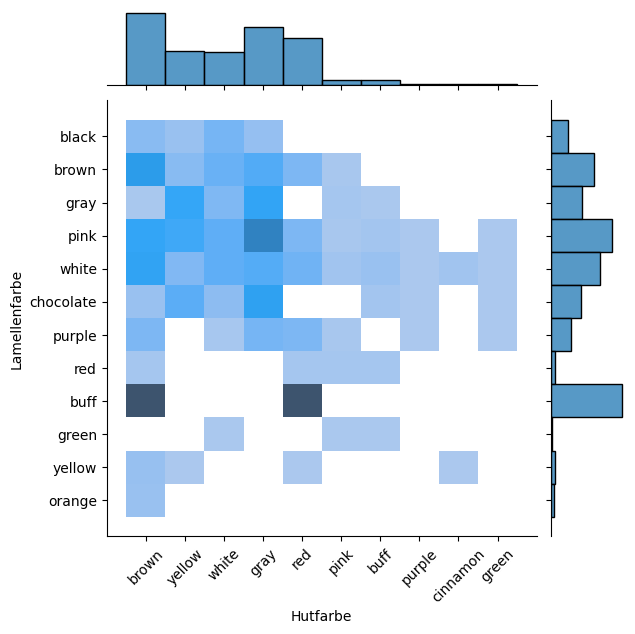

In [9]:
# Randverteilungen mit jointplot
# jointplot: https://seaborn.pydata.org/generated/seaborn.jointplot.html
fig = sea.jointplot(data=pilze, x='Hutfarbe', y='Lamellenfarbe', kind='hist')
fig.ax_joint.set_xticklabels(fig.ax_joint.get_xticklabels(),rotation=45)
plt.show()

In [10]:
# bedingte Häufigkeiten
# P(Lamellenfarbe=brown | Hutfarbe = brown)
hij = 348
hsj = 2284
print('P(Lamellenfarbe=brown | Hutfarbe = brown) : {0:.4f}'.format(hij/hsj))
df=pd.crosstab(pilze['Hutfarbe'], pilze['Lamellenfarbe'], margins=True, normalize='index')
display(df.loc['brown'])

P(Lamellenfarbe=brown | Hutfarbe = brown) : 0.1524


Lamellenfarbe
black        0.0473
brown        0.1524
buff         0.3783
chocolate    0.0280
gray         0.0053
green        0.0000
orange       0.0280
pink         0.1243
purple       0.0630
red          0.0105
white        0.1322
yellow       0.0306
Name: brown, dtype: float64

In [11]:
# P(Hutfarbe = brown | Lamellenfarbe=brown)
hij = 348
hsj = 1048
print('P(Hutfarbe = brown | Lamellenfarbe=brown) : {0:.4f}'.format(hij/hsj))
df=pd.crosstab(pilze['Hutfarbe'], pilze['Lamellenfarbe'], margins=True, normalize='columns')
display(df.loc[:'brown'])

P(Hutfarbe = brown | Lamellenfarbe=brown) : 0.3321


Lamellenfarbe,black,brown,buff,chocolate,gray,green,orange,pink,purple,red,white,yellow,All
Hutfarbe,,,,,,,,,,,,,
brown,0.2647,0.3321,0.5,0.0874,0.016,0.0,1.0,0.1903,0.2927,0.25,0.2512,0.814,0.2811


## Frage

Bestimme die Kreuztabelle für die Merkmale *Hüllenfarbe* und *Klasse*. In der Kreuztabelle sollen die absoluten Randhäufigkeiten ablesbar sein. Wie lauten die bedingten Häufigkeiten für:
- P(Klasse=edible | Hüllenfarbe=orange)
- P(Hüllenfarbe=yellow | Klasse=poisonous)
- P(Hüllenfarbe=white | Klasse=poisonous)
- P(Klasse=poisonous | Hüllenfarbe=white)

In [12]:
# corrected indexing + formatting
ct2 = pd.crosstab(pilze['Klasse'], pilze['Hüllenfarbe'], margins=True)
display(ct2)

print(f"P(Klasse=edible | Hüllenfarbe=orange): {ct2.loc['edible','orange'] / ct2.loc['All','orange']:.4f}")
print(f"P(Hüllenfarbe=yellow | Klasse=poisonous): {ct2.loc['poisonous','yellow'] / ct2.loc['poisonous','All']:.4f}")
print(f"P(Hüllenfarbe=white | Klasse=poisonous): {ct2.loc['poisonous','white'] / ct2.loc['poisonous','All']:.4f}")
print(f"P(Klasse=poisonous | Hüllenfarbe=white): {ct2.loc['poisonous','white'] / ct2.loc['All','white']:.4f}")

Hüllenfarbe,brown,orange,white,yellow,All
Klasse,,,,,
edible,96,96,4016,0,4208
poisonous,0,0,3908,8,3916
All,96,96,7924,8,8124


P(Klasse=edible | Hüllenfarbe=orange): 1.0000
P(Hüllenfarbe=yellow | Klasse=poisonous): 0.0020
P(Hüllenfarbe=white | Klasse=poisonous): 0.9980
P(Klasse=poisonous | Hüllenfarbe=white): 0.4932


## Kontingenzkoeffizient

In [13]:
# einfaches Beispiel
df = pilze[(pilze['Hüllenfarbe'] == 'yellow') | (pilze['Hüllenfarbe'] == 'orange')]
ktab = pd.crosstab(df['Hüllenfarbe'], df['Klasse'], margins=False)
display(ktab)

# Bestimmung der statistischen Abhängigkeit
# chi2_contingency: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html
chi2, pValue, dof, expFreq = contingency.chi2_contingency(ktab, correction=False)
print('Teststatistik (chi-quadrat): {0:.4f}'.format(chi2))
print('P-Wert: {0:.4f}'.format(pValue))
print('Freiheitsgrade: {0:d}'.format(dof))
print('erwartete Häufigkeiten')
expFreqDF = pd.DataFrame(expFreq, index=ktab.index, columns= ktab.columns)
display(expFreqDF)

# Korrektur
npoints = df.shape[0] # Anzahl an Beobachtungen
nExpr = min(ktab.shape) # minimale Anzahl an Ausprägungen bei den beiden Merkmalen
ub = npoints*(nExpr-1) # oberes limit
print('Obere Grenze für Chi-Quadrat: {0:.4f}'.format(ub))
# Wert für Kontingenzkoeffizient nach Pearson
print('Pearson: {0:.4f} (max. {1:.4f})'.format(np.sqrt(chi2/(npoints+chi2)),np.sqrt((nExpr-1)/nExpr)))
print('Pearson normalisiert: {0:.4f} (max. 1)'.format(np.sqrt(chi2/(npoints+chi2))*np.sqrt(nExpr/(nExpr-1))))

Klasse,edible,poisonous
Hüllenfarbe,,
orange,96,0
yellow,0,8


Teststatistik (chi-quadrat): 104.0000
P-Wert: 0.0000
Freiheitsgrade: 1
erwartete Häufigkeiten


Klasse,edible,poisonous
Hüllenfarbe,,
orange,88.6154,7.3846
yellow,7.3846,0.6154


Obere Grenze für Chi-Quadrat: 104.0000
Pearson: 0.7071 (max. 0.7071)
Pearson normalisiert: 1.0000 (max. 1)


In [14]:
# selbes problem aber zusätzlich mit Pilzen mit weißer Hüllenfarbe
df = pilze[(pilze['Hüllenfarbe'] == 'yellow') | (pilze['Hüllenfarbe'] == 'orange') | (pilze['Hüllenfarbe'] == 'white')]
ktab = pd.crosstab(df['Hüllenfarbe'], df['Klasse'], margins=False)
display(ktab)

# Bestimmung der statistischen Abhängigkeit
chi2, pValue, dof, expFreq = contingency.chi2_contingency(ktab)
print('Teststatistik (chi-quadrat): {0:.4f}'.format(chi2))
print('P-Wert: {0:.4f}'.format(pValue))
print('Freiheitsgrade: {0:d}'.format(dof))
print('erwartete Häufigkeiten')
expFreqDF = pd.DataFrame(expFreq, index=ktab.index, columns= ktab.columns)
display(expFreqDF)

# Korrektur
npoints = df.shape[0] # Anzahl an Beobachtungen
nExpr = min(ktab.shape) # minimale Anzahl an Ausprägungen bei den beiden Merkmalen
ub = npoints*(nExpr-1) # oberes limit
print('Obere Grenze für Chi-Quadrat: {0:.4f}'.format(ub))
# Wert für Kontingenzkoeffizient nach Pearson
print('Pearson: {0:.4f} (max. {1:.4f})'.format(np.sqrt(chi2/(npoints+chi2)),np.sqrt((nExpr-1)/nExpr)))
print('Pearson korrigiert: {0:.4f} (max. 1)'.format(np.sqrt(chi2/(npoints+chi2))*np.sqrt(nExpr/(nExpr-1))))

Klasse,edible,poisonous
Hüllenfarbe,,
orange,96,0
white,4016,3908
yellow,0,8


Teststatistik (chi-quadrat): 100.7468
P-Wert: 0.0000
Freiheitsgrade: 2
erwartete Häufigkeiten


Klasse,edible,poisonous
Hüllenfarbe,,
orange,49.1719,46.8281
white,4058.7304,3865.2696
yellow,4.0977,3.9023


Obere Grenze für Chi-Quadrat: 8028.0000
Pearson: 0.1113 (max. 0.7071)
Pearson korrigiert: 0.1574 (max. 1)


In [15]:
# selbes problem aber zusätzlich mit Pilzen mit weißer Hüllenfarbe
df = pilze
ktab = pd.crosstab(df['Hutfarbe'], df['Klasse'], margins=False)
display(ktab)

# Bestimmung der statistischen Abhängigkeit
chi2, pValue, dof, expFreq = contingency.chi2_contingency(ktab)
print('Teststatistik (chi-quadrat): {0:.4f}'.format(chi2))
print('P-Wert: {0:.4f}'.format(pValue))
print('Freiheitsgrade: {0:d}'.format(dof))
print('erwartete Häufigkeiten')
expFreqDF = pd.DataFrame(expFreq, index=ktab.index, columns= ktab.columns)
display(expFreqDF)

# Korrektur
npoints = df.shape[0] # Anzahl an Beobachtungen
nExpr = min(ktab.shape) # minimale Anzahl an Ausprägungen bei den beiden Merkmalen
ub = npoints*(nExpr-1) # oberes limit
print('Obere Grenze für Chi-Quadrat: {0:.4f}'.format(ub))
# Wert für Kontingenzkoeffizient nach Pearson
print('Pearson: {0:.4f} (max. {1:.4f})'.format(np.sqrt(chi2/(npoints+chi2)),np.sqrt((nExpr-1)/nExpr)))
print('Pearson korrigiert: {0:.4f} (max. 1)'.format(np.sqrt(chi2/(npoints+chi2))*np.sqrt(nExpr/(nExpr-1))))

# kann auch mittels contingency.association(ktab, method='pearson') ermittelt werden
pearson = contingency.association(ktab, method='pearson')
print('mit association-Methode, Pearson: {0:.4f}'.format(pearson))
print('mit association-Methode, Pearson korrigiert: {0:.4f} (max. 1)'.format(pearson*np.sqrt(nExpr/(nExpr-1))))

Klasse,edible,poisonous
Hutfarbe,,
brown,1264,1020
buff,48,120
cinnamon,32,12
gray,1032,808
green,16,0
pink,56,88
purple,16,0
red,624,876
white,720,320


Teststatistik (chi-quadrat): 387.5978
P-Wert: 0.0000
Freiheitsgrade: 9
erwartete Häufigkeiten


Klasse,edible,poisonous
Hutfarbe,,
brown,1183.0468,1100.9532
buff,87.0192,80.9808
cinnamon,22.7907,21.2093
gray,953.0675,886.9325
green,8.2875,7.7125
pink,74.5879,69.4121
purple,8.2875,7.7125
red,776.9572,723.0428
white,538.6903,501.3097


Obere Grenze für Chi-Quadrat: 8124.0000
Pearson: 0.2134 (max. 0.7071)
Pearson korrigiert: 0.3018 (max. 1)
mit association-Methode, Pearson: 0.2134
mit association-Methode, Pearson korrigiert: 0.3018 (max. 1)


## Frage

Berechne und interpretiere den korrigierten Kontingenzkoeffizienten nach Pearson für folgende Merkmalskombinationen:
- Klasse und Hutfarbe
- Lamellen- und Sporenpulverfarbe
  

In [16]:
df = pilze
ktab = pd.crosstab(df['Klasse'], df['Hutfarbe'], margins=False)
display(ktab)
print("\n")
# Bestimmung der statistischen Abhängigkeit
chi2, pValue, dof, expFreq = contingency.chi2_contingency(ktab)
expFreqDF = pd.DataFrame(expFreq, index=ktab.index, columns= ktab.columns)
display(expFreqDF)

# Korrektur
npoints = df.shape[0] # Anzahl an Beobachtungen
nExpr = min(ktab.shape) # minimale Anzahl an Ausprägungen bei den beiden Merkmalen
ub = npoints*(nExpr-1) # oberes limit

# Wert für Kontingenzkoeffizient nach Pearson
print("\n"'Pearson: {0:.4f} (max. {1:.4f})'.format(np.sqrt(chi2/(npoints+chi2)),np.sqrt((nExpr-1)/nExpr)))
print('Pearson korrigiert: {0:.4f} (max. 1)'.format(np.sqrt(chi2/(npoints+chi2))*np.sqrt(nExpr/(nExpr-1))))

Hutfarbe,brown,buff,cinnamon,gray,green,pink,purple,red,white,yellow
Klasse,,,,,,,,,,
edible,1264,48,32,1032,16,56,16,624,720,400
poisonous,1020,120,12,808,0,88,0,876,320,672


Hutfarbe,brown,buff,cinnamon,gray,green,pink,purple,red,white,yellow
Klasse,,,,,,,,,,
edible,1183.0468,87.0192,22.7907,953.0675,8.2875,74.5879,8.2875,776.9572,538.6903,555.2654
poisonous,1100.9532,80.9808,21.2093,886.9325,7.7125,69.4121,7.7125,723.0428,501.3097,516.7346



Pearson: 0.2134 (max. 0.7071)
Pearson korrigiert: 0.3018 (max. 1)


## Quantitative Daten

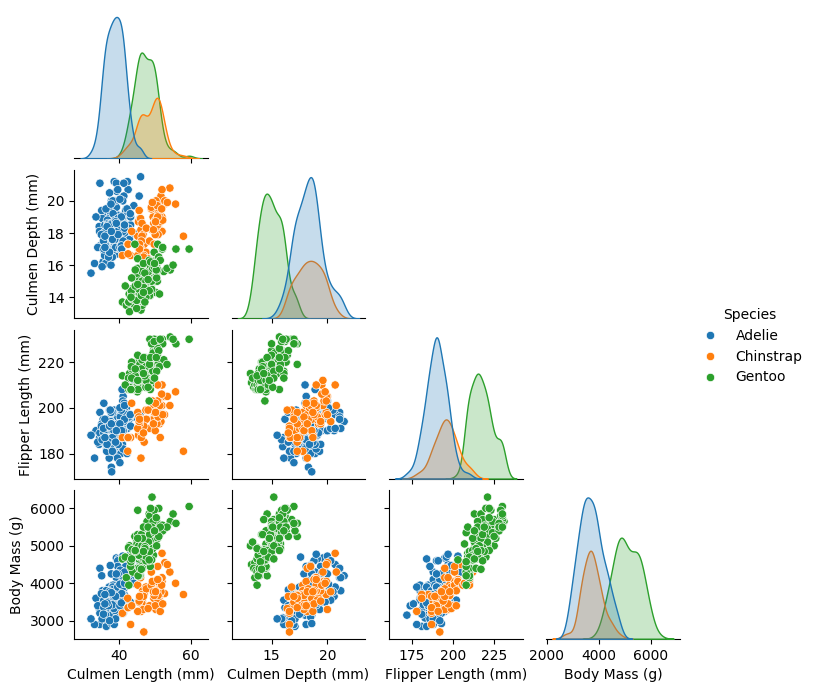

In [ ]:
# einladen des Pinguin-Datensatzes
penguins = pd.read_excel('penguinsSmall.xlsx', index_col=0)

# pairplot als anschauliche Darstellung der Zusammenhänge
# pairplot: https://seaborn.pydata.org/generated/seaborn.pairplot.html
sea.pairplot(data = penguins, kind='scatter', corner=True, hue='Species', height=1.75)
plt.show()

## Frage

Erstelle einen pairplot mit:
- kde-Plots für die einzelnen Merkmalspaarungen
- Histogrammen entlang der Diagonalen
- Farbkodierung basierend auf dem Geschlecht

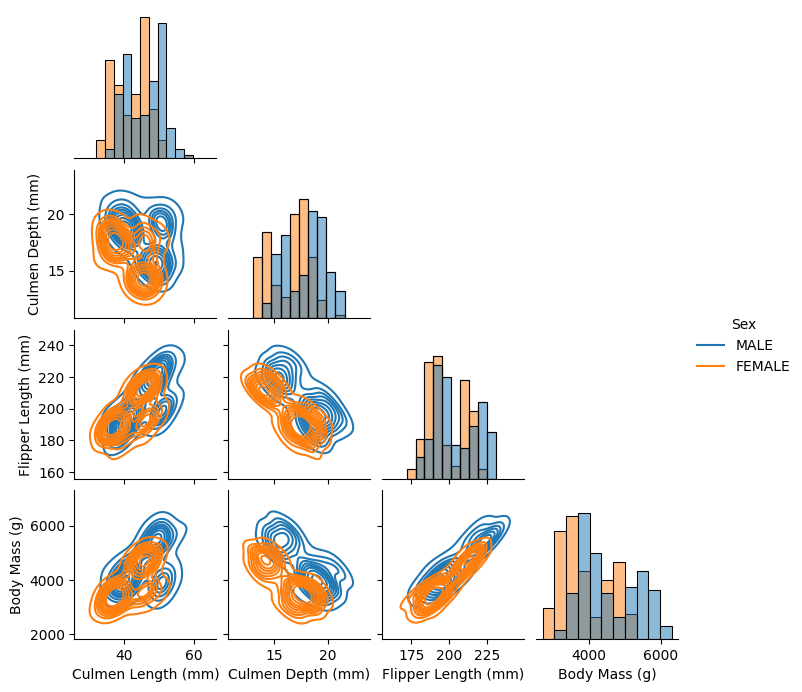

In [23]:
penguins2 = pd.read_excel('penguinsSmall2.xlsx', index_col=0)

sea.pairplot(data = penguins2, kind='kde', diag_kind='hist', corner=True, hue='Sex', height=1.75)
plt.show()

## Frage

Berechne für die einzelnen Merkmalspaarungen die entsprechenden Kovarianz. Verwende dazu die Methode [np.cov()](https://numpy.org/doc/stable/reference/generated/numpy.cov.html). Bestimme anschließend die entsprechenden Korrelationen **rechnerisch**. Überprüfe dein Ergebnis mithilfe der [corr-Methode](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) von pandas.